## Following the framework in Truong et al. (2020), a standard CPD pipeline includes five core steps:

- Step 1: Define the signal
- Step 2: Define the type of change
- Step 3: Select the optimization/search method
- Step 4: Determine the number of change points (constraints)
- Step 5: Evaluate and validate the results

Before entering this pipeline, we first prepare the input data.

### Step 1: Define the Signal

Following Truong et al. (2020) change point detection review, the first step is to prepare the time series data by defining the signal, including the variable, time index, and preprocessing approach.

**Objective**  
Prepare time series data — what data will be analyzed?

**Decision Made**  
- **X**: sequential PA index (e.g., `pa_seq_id`)  
- **Y**: corresponding feature value, including:
  - Hitting Decisions  
  - Power Efficiency  
  - Luck vs. Skill  
  - Launch Angle Stability  

We filter by player, remove missing values, and sort by the sequence index to ensure a properly ordered time series.

In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import ruptures as rpt
import matplotlib.pyplot as plt

In [2]:
# --- 1. Load data ---
DATA_FILE = 'Qualified_hitters_statcast_2021_2025_pa_master.csv'
csv_path = Path(os.getcwd()).parent / 'data' / 'processed' / DATA_FILE
df = pd.read_csv(csv_path)

# --- 2. Data availability summary for the four CPD indicators ---
CPD_INDICATORS = [
    'hitting_decisions_score',
    'power_efficiency',
    'woba_residual',
    'launch_angle_stability_50pa',
]

summary_df = pd.DataFrame({
    'indicator': CPD_INDICATORS,
    'rows_with_value': [df[col].notna().sum() for col in CPD_INDICATORS],
})
summary_df['pct_of_total'] = (summary_df['rows_with_value'] / len(df) * 100).round(2)

print(f"Total rows: {len(df):,}  |  Total batters: {df['batter'].nunique()}")
display(summary_df)


Total rows: 601,449  |  Total batters: 420


,indicator,rows_with_value,pct_of_total
0,hitting_decisions_score,601449,100.00
1,power_efficiency,394994,65.67
2,woba_residual,394994,65.67
3,launch_angle_stability_50pa,383012,63.68


In [3]:
def cpd_subdataset_generator(df, selected_player_id):
    """
    Generate four CPD subdatasets for one player.

    Parameters
    ----------
    df : pandas.DataFrame
        Original PA-level dataframe.
    selected_player_id : int
        MLBAM batter id.

    Returns
    -------
    dict[str, pandas.DataFrame]
        Keys: cpd_decision, cpd_power_efficiency,
              cpd_woba_residual, cpd_launch_angle_stability
    """
    base_cols = ["batter", "pa_uid", "game_date", "game_pk", "at_bat_number"]

    def _build_subdataset(x_col, y_col):
        return (
            df.loc[df["batter"] == selected_player_id, base_cols + [x_col, y_col]]
              .dropna(subset=[x_col, y_col])
              .sort_values(x_col)
              .reset_index(drop=True)
        )

    return {
        "cpd_decision": _build_subdataset("pa_seq_id", "hitting_decisions_score"),
        "cpd_power_efficiency": _build_subdataset("power_woba_seq_id", "power_efficiency"),
        "cpd_woba_residual": _build_subdataset("power_woba_seq_id", "woba_residual"),
        "cpd_launch_angle_stability": _build_subdataset("launch_angle_seq_id", "launch_angle_stability_50pa"),
    }


# Example usage
SELECTED_PLAYER_ID = 660271  # e.g. Shohei Ohtani
cpd_subdatasets = cpd_subdataset_generator(df, SELECTED_PLAYER_ID)

cpd_decision = cpd_subdatasets["cpd_decision"]
cpd_power_efficiency = cpd_subdatasets["cpd_power_efficiency"]
cpd_woba_residual = cpd_subdatasets["cpd_woba_residual"]
cpd_launch_angle_stability = cpd_subdatasets["cpd_launch_angle_stability"]

{
    "cpd_decision_rows": len(cpd_decision),
    "cpd_power_efficiency_rows": len(cpd_power_efficiency),
    "cpd_woba_residual_rows": len(cpd_woba_residual),
    "cpd_launch_angle_stability_rows": len(cpd_launch_angle_stability),
}


{'cpd_decision_rows': 3599,
 'cpd_power_efficiency_rows': 2116,
 'cpd_woba_residual_rows': 2116,
 'cpd_launch_angle_stability_rows': 2087}

In [4]:
cpd_decision.describe()

,batter,game_pk,at_bat_number,pa_seq_id,hitting_decisions_score
count,3599.0,3599.000000,3599.000000,3599.000000,3599.000000
mean,660271.0,713434.159767,34.980828,1800.000000,0.591275
std,0.0,54937.793183,23.846273,1039.086137,2.752217
min,660271.0,632197.000000,1.000000,1.000000,-11.000000
25%,660271.0,662169.500000,17.000000,900.500000,-1.000000
50%,660271.0,718235.000000,35.000000,1800.000000,1.000000
75%,660271.0,747801.000000,55.000000,2699.500000,2.000000
max,660271.0,813069.000000,146.000000,3599.000000,10.000000


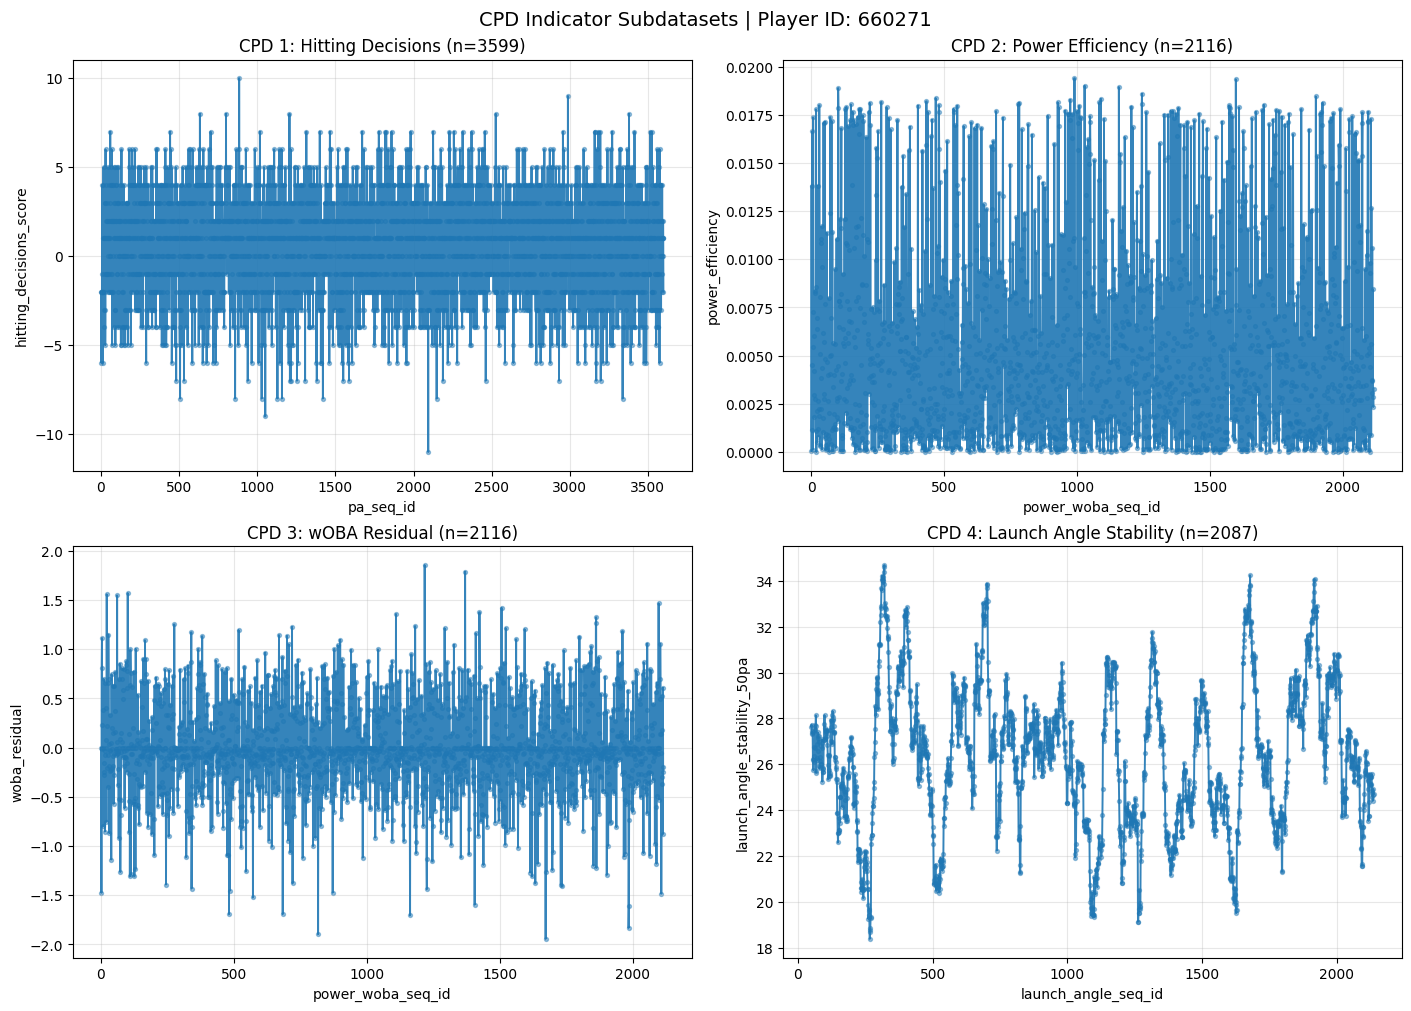

In [5]:
def cpd_subdataset_graph_generator(cpd_subdatasets, selected_player_id=None, figsize=(14, 10)):
    """
    Plot the 4 CPD subdatasets as a 2x2 panel.

    Parameters
    ----------
    cpd_subdatasets : dict[str, pandas.DataFrame]
        Output from cpd_subdataset_generator.
    selected_player_id : int | None
        Optional, used for figure title.
    figsize : tuple[int, int]
        Figure size for matplotlib.

    Returns
    -------
    (fig, axes)
        Matplotlib figure and axes array.
    """
    plot_specs = [
        ("cpd_decision", "pa_seq_id", "hitting_decisions_score", "CPD 1: Hitting Decisions"),
        ("cpd_power_efficiency", "power_woba_seq_id", "power_efficiency", "CPD 2: Power Efficiency"),
        ("cpd_woba_residual", "power_woba_seq_id", "woba_residual", "CPD 3: wOBA Residual"),
        (
            "cpd_launch_angle_stability",
            "launch_angle_seq_id",
            "launch_angle_stability_50pa",
            "CPD 4: Launch Angle Stability",
        ),
    ]

    fig, axes = plt.subplots(2, 2, figsize=figsize, constrained_layout=True)
    axes = axes.flatten()

    for ax, (key, x_col, y_col, title) in zip(axes, plot_specs):
        subdf = cpd_subdatasets.get(key)

        if subdf is None or subdf.empty:
            ax.set_title(f"{title} (no data)")
            ax.set_xlabel(x_col)
            ax.set_ylabel(y_col)
            ax.grid(alpha=0.3)
            continue

        ax.plot(subdf[x_col], subdf[y_col], linewidth=1.4, alpha=0.9)
        ax.scatter(subdf[x_col], subdf[y_col], s=8, alpha=0.45)
        ax.set_title(f"{title} (n={len(subdf)})")
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)
        ax.grid(alpha=0.3)

    fig.suptitle(
        "CPD Indicator Subdatasets" if selected_player_id is None else f"CPD Indicator Subdatasets | Player ID: {selected_player_id}",
        fontsize=14,
    )

    return fig, axes


# Example usage
fig, axes = cpd_subdataset_graph_generator(cpd_subdatasets, selected_player_id=SELECTED_PLAYER_ID)
plt.show()

### 2. Define the Type of Change (Cost Function)

Different cost functions are used to capture different types of structural changes in the signal:

L2 (Least Squares)
Detects changes in the mean level of the signal (mean shift).
RBF (Radial Basis Function)
Captures more general distributional changes, including nonlinear patterns and variance shifts.
Normal Model
Assumes a Gaussian distribution and detects changes in both mean and variance.

Given that some indicators exhibit relatively stable mean but changing variability, models beyond simple mean shift (e.g., RBF, Normal) are considered.

### 3. Choose Optimization Strategy (Search Method)

We adopt the PELT (Pruned Exact Linear Time) algorithm for change point detection.

PELT provides an exact solution to the penalized segmentation problem
It efficiently identifies globally optimal change points
It is suitable for long time series (e.g., thousands of observations)

### 4. Determine Number of Changes (Constraint)

The number of detected change points is controlled by a penalty parameter (pen):

Lower penalty → more change points (risk of overfitting)
Higher penalty → fewer change points (risk of underfitting)

The penalty parameter is tuned to balance sensitivity and interpretability of detected regimes.

### 5. Evaluate & Validate

The detected change points are evaluated using:

Visual inspection
Checking whether change points align with visible shifts in the smoothed signal
Sensitivity analysis
Assessing robustness with respect to:
rolling window size
penalty parameter
Domain interpretation
Verifying whether detected regimes correspond to meaningful changes in player performance or behavior

In [ ]:
CPD_SIGNAL_SPECS = {
    "cpd_decision": ("pa_seq_id", "hitting_decisions_score", "CPD 1: Hitting Decisions"),
    "cpd_power_efficiency": ("power_woba_seq_id", "power_efficiency", "CPD 2: Power Efficiency"),
    "cpd_woba_residual": ("power_woba_seq_id", "woba_residual", "CPD 3: wOBA Residual"),
    "cpd_launch_angle_stability": (
        "launch_angle_seq_id",
        "launch_angle_stability_50pa",
        "CPD 4: Launch Angle Stability",
    ),
}


def detect_mean_shift(subdf, x_col, y_col, model="rbf", pen=12, min_size=50, jump=1):
    """
    Detect mean shifts in a univariate CPD subdataset using PELT.

    Returns a dictionary containing breakpoint indices, x-axis positions,
    and a compact summary table.
    """
    if subdf.empty:
        return {
            "breakpoints": [],
            "breakpoint_x": [],
            "summary": pd.DataFrame(columns=["breakpoint_index", x_col, y_col]),
        }

    signal = subdf[[y_col]].to_numpy()
    algo = rpt.Pelt(model=model, min_size=min_size, jump=jump).fit(signal)
    raw_breakpoints = algo.predict(pen=pen)

    breakpoints = [bp for bp in raw_breakpoints if bp < len(subdf)]
    breakpoint_x = [subdf.iloc[bp][x_col] for bp in breakpoints]

    summary = pd.DataFrame(
        {
            "breakpoint_index": breakpoints,
            x_col: breakpoint_x,
            y_col: [subdf.iloc[bp][y_col] for bp in breakpoints],
        }
    )

    return {
        "breakpoints": breakpoints,
        "breakpoint_x": breakpoint_x,
        "summary": summary,
    }


def plot_mean_shift_result(subdf, x_col, y_col, title, mean_shift_result, figsize=(12, 4)):
    """Plot one CPD signal with vertical lines at detected mean-shift breakpoints."""
    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(subdf[x_col], subdf[y_col], linewidth=1.4, alpha=0.9, label=y_col)
    ax.scatter(subdf[x_col], subdf[y_col], s=10, alpha=0.35)

    for i, x_value in enumerate(mean_shift_result["breakpoint_x"]):
        ax.axvline(
            x=x_value,
            color="crimson",
            linestyle="--",
            linewidth=1.2,
            alpha=0.85,
            label="detected mean shift" if i == 0 else None,
        )

    ax.set_title(title)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.grid(alpha=0.3)
    ax.legend()
    return fig, ax


# Example: run mean-shift detection on one selected CPD signal
SELECTED_SIGNAL_KEY = "cpd_decision"
x_col, y_col, title = CPD_SIGNAL_SPECS[SELECTED_SIGNAL_KEY]
selected_subdf = cpd_subdatasets[SELECTED_SIGNAL_KEY]

mean_shift_result = detect_mean_shift(
    selected_subdf,
    x_col=x_col,
    y_col=y_col,
    model="rbf",
    pen=40,
    min_size=50,
)

display(mean_shift_result["summary"])
plot_mean_shift_result(
    selected_subdf,
    x_col=x_col,
    y_col=y_col,
    title=f"{title} | Mean Shift Detection | Player ID: {SELECTED_PLAYER_ID}",
    mean_shift_result=mean_shift_result,
)
plt.show()


In [14]:
def run_mean_shift_for_all_subdatasets(
    cpd_subdatasets,
    signal_specs,
    model="l2",
    pen=12,
    min_size=50,
    jump=1,
):
    """Run mean-shift detection for all CPD subdatasets."""
    results = {}

    for key, (x_col, y_col, title) in signal_specs.items():
        subdf = cpd_subdatasets.get(key, pd.DataFrame())
        detection_result = detect_mean_shift(
            subdf,
            x_col=x_col,
            y_col=y_col,
            model=model,
            pen=pen,
            min_size=min_size,
            jump=jump,
        )
        results[key] = {
            "x_col": x_col,
            "y_col": y_col,
            "title": title,
            "subdf": subdf,
            "detection": detection_result,
        }

    return results


def plot_mean_shift_for_all_subdatasets(
    all_results,
    selected_player_id=None,
    figsize=(14, 10),
):
    """Plot mean-shift results for all four CPD subdatasets in a 2x2 panel."""
    fig, axes = plt.subplots(2, 2, figsize=figsize, constrained_layout=True)
    axes = axes.flatten()

    for ax, (key, result) in zip(axes, all_results.items()):
        subdf = result["subdf"]
        x_col = result["x_col"]
        y_col = result["y_col"]
        title = result["title"]
        breakpoint_x = result["detection"]["breakpoint_x"]

        if subdf.empty:
            ax.set_title(f"{title} (no data)")
            ax.set_xlabel(x_col)
            ax.set_ylabel(y_col)
            ax.grid(alpha=0.3)
            continue

        ax.plot(subdf[x_col], subdf[y_col], linewidth=1.3, alpha=0.9, label=y_col)
        ax.scatter(subdf[x_col], subdf[y_col], s=8, alpha=0.3)

        for i, x_value in enumerate(breakpoint_x):
            ax.axvline(
                x=x_value,
                color="crimson",
                linestyle="--",
                linewidth=1.1,
                alpha=0.8,
                label="detected mean shift" if i == 0 else None,
            )

        ax.set_title(f"{title} (n={len(subdf)}, bkps={len(breakpoint_x)})")
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)
        ax.grid(alpha=0.3)
        ax.legend()

    figure_title = "Mean Shift Detection Across 4 CPD Indicators"
    if selected_player_id is not None:
        figure_title += f" | Player ID: {selected_player_id}"
    fig.suptitle(figure_title, fontsize=14)

    return fig, axes


all_mean_shift_results = run_mean_shift_for_all_subdatasets(
    cpd_subdatasets,
    CPD_SIGNAL_SPECS,
    model="l2",
    pen=50,
    min_size=50,
)

all_mean_shift_summary = pd.concat(
    [
        result["detection"]["summary"].assign(indicator=key)
        for key, result in all_mean_shift_results.items()
    ],
    ignore_index=True,
)

summary_counts = pd.DataFrame(
    {
        "indicator": list(all_mean_shift_results.keys()),
        "n_rows": [len(result["subdf"]) for result in all_mean_shift_results.values()],
        "n_breakpoints": [len(result["detection"]["breakpoints"]) for result in all_mean_shift_results.values()],
    }
)

display(summary_counts)
display(all_mean_shift_summary.head(20))

# fig, axes = plot_mean_shift_for_all_subdatasets(
#     all_mean_shift_results,
#     selected_player_id=SELECTED_PLAYER_ID,
# )
# plt.show()


,indicator,n_rows,n_breakpoints
0,cpd_decision,3599,2
1,cpd_power_efficiency,2116,0
2,cpd_woba_residual,2116,0
3,cpd_launch_angle_stability,2087,28


,breakpoint_index,pa_seq_id,hitting_decisions_score,indicator,power_woba_seq_id,power_efficiency,woba_residual,launch_angle_seq_id,launch_angle_stability_50pa
0,1376.0,1377.0,0.0,cpd_decision,NaN,NaN,NaN,NaN,NaN
1,1426.0,1427.0,0.0,cpd_decision,NaN,NaN,NaN,NaN,NaN
2,92.0,NaN,NaN,cpd_launch_angle_stability,NaN,NaN,NaN,142.0,25.791028
3,170.0,NaN,NaN,cpd_launch_angle_stability,NaN,NaN,NaN,220.0,23.077235
4,236.0,NaN,NaN,cpd_launch_angle_stability,NaN,NaN,NaN,286.0,26.971217
5,287.0,NaN,NaN,cpd_launch_angle_stability,NaN,NaN,NaN,337.0,30.229976
6,370.0,NaN,NaN,cpd_launch_angle_stability,NaN,NaN,NaN,420.0,27.525128
7,440.0,NaN,NaN,cpd_launch_angle_stability,NaN,NaN,NaN,490.0,24.273350
8,499.0,NaN,NaN,cpd_launch_angle_stability,NaN,NaN,NaN,549.0,25.258185
9,612.0,NaN,NaN,cpd_launch_angle_stability,NaN,NaN,NaN,662.0,31.261791


In [15]:
# Step 2: Mean Shift Signal Preparation (for CPD models)

def build_mean_shift_signal(df, x_col, y_col):
    """
    Convert CPD subdataset into signal for mean-shift detection.
    """
    signal_df = (
        df[[x_col, y_col]]
        .dropna()
        .sort_values(x_col)
        .reset_index(drop=True)
        .copy()
    )

    # y_t → shape (n, 1) for CPD models
    signal = signal_df[y_col].to_numpy().reshape(-1, 1)

    return signal_df, signal


# --- Build signals for 4 indicators ---
decision_df, decision_signal = build_mean_shift_signal(
    cpd_decision, "pa_seq_id", "hitting_decisions_score"
)

power_df, power_signal = build_mean_shift_signal(
    cpd_power_efficiency, "power_woba_seq_id", "power_efficiency"
)

woba_df, woba_signal = build_mean_shift_signal(
    cpd_woba_residual, "power_woba_seq_id", "woba_residual"
)

launch_df, launch_signal = build_mean_shift_signal(
    cpd_launch_angle_stability, "launch_angle_seq_id", "launch_angle_stability_50pa"
)

print(decision_signal.shape, power_signal.shape, woba_signal.shape, launch_signal.shape)

(3599, 1) (2116, 1) (2116, 1) (2087, 1)


### Step 3: Select the Optimization/Search Method

Following Truong et al. (2020) change point detection review, the third step is to choose how to search for structural breakpoints in the time series.

**Objective**  
Select an optimization/search strategy that can efficiently detect change points in player-level feature series.

**Decision Made**  
- **Search method**: PELT  
- **Cost model**: L2  

We use PELT as the main segmentation algorithm because it is computationally efficient and suitable for detecting multiple change points in a univariate signal. Combined with the L2 cost, it provides a natural baseline for mean-shift detection.

**Output**  
A segmentation algorithm that returns candidate breakpoints for each player-feature time series.

In [32]:
# Step 3: Select the Optimization/Search Method
# Mean shift baseline: PELT + L2 cost

import ruptures as rpt

def run_pelt_mean_shift(signal, pen=0.000001):
    """
    Run mean-shift CPD using PELT with L2 cost.

    Parameters
    ----------
    signal : np.ndarray
        Shape (n, 1)
    pen : int | float
        Penalty controlling number of breakpoints

    Returns
    -------
    list[int]
        Breakpoint indices (last point included by ruptures)
    """
    algo = rpt.Pelt(model="l2").fit(signal)
    bkpts = algo.predict(pen=pen)
    return bkpts


# --- Run PELT on 4 indicators ---
decision_bkpts = run_pelt_mean_shift(decision_signal, pen=40) # use grid search to find good pen value for each signal
power_bkpts = run_pelt_mean_shift(power_signal, pen=10)
woba_bkpts = run_pelt_mean_shift(woba_signal, pen=10)
launch_bkpts = run_pelt_mean_shift(launch_signal, pen=500)

print("decision_bkpts:", decision_bkpts)
print("power_bkpts:", power_bkpts)
print("woba_bkpts:", woba_bkpts)
print("launch_bkpts:", launch_bkpts)

# for pen in [10, 50, 100, 200, 500, 1000]:
#     bkpts = run_pelt_mean_shift(decision_signal, pen=pen)
#     print(f"pen={pen}, #bkpts={len(bkpts)}")

decision_bkpts: [15, 1025, 1030, 1400, 1420, 2090, 2095, 2225, 2235, 3599]
power_bkpts: [2116]
woba_bkpts: [2116]
launch_bkpts: [170, 235, 370, 440, 500, 1010, 1080, 1140, 1235, 1305, 1600, 1650, 1770, 1965, 2087]


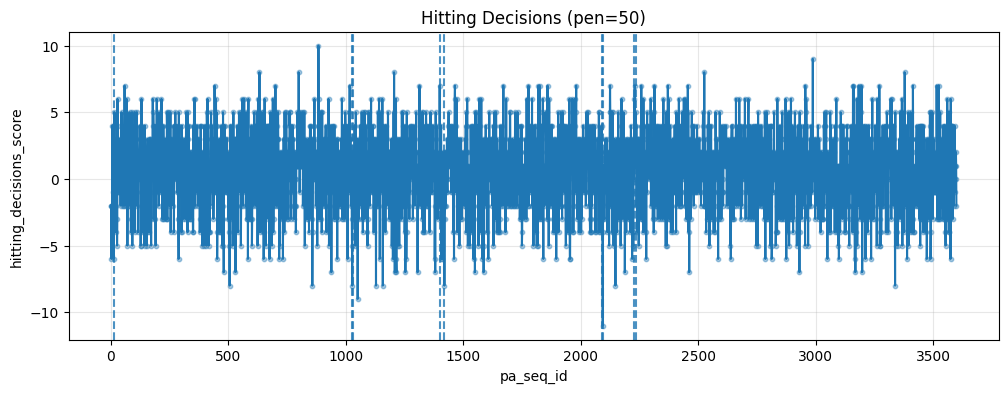

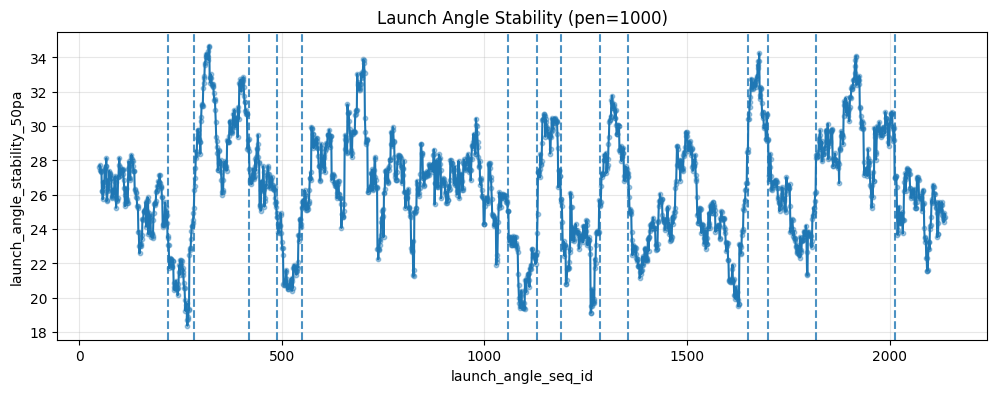

# of internal change points:
decision: 9
launch: 14


In [ ]:
def plot_cp_result(signal_df, x_col, y_col, bkpts, title="CPD Result"):
    fig, ax = plt.subplots(figsize=(12, 4))

    ax.plot(signal_df[x_col], signal_df[y_col], linewidth=1.5)
    ax.scatter(signal_df[x_col], signal_df[y_col], s=10, alpha=0.4)

    for bp in bkpts[:-1]:  # skip last endpoint
        ax.axvline(signal_df.iloc[bp - 1][x_col], linestyle="--", alpha=0.8)

    ax.set_title(title)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.grid(alpha=0.3)
    plt.show()

# Remove last endpoint (not a real change point)
decision_internal_bkpts = decision_bkpts[:-1]
launch_internal_bkpts = launch_bkpts[:-1]

# --- Plot decision (pen=50) ---
plot_cp_result(
    decision_df,
    x_col="pa_seq_id",
    y_col="hitting_decisions_score",
    bkpts=decision_bkpts,
    title="Hitting Decisions (pen=50)"
)

# --- Plot launch (pen=1000) ---
plot_cp_result(
    launch_df,
    x_col="launch_angle_seq_id",
    y_col="launch_angle_stability_50pa",
    bkpts=launch_bkpts,
    title="Launch Angle Stability (pen=1000)"
)

# --- Summary ---
print("# of internal change points:")
print("decision:", len(decision_internal_bkpts))
print("launch:", len(launch_internal_bkpts))

In [35]:
def apply_mean_shift_smoothing(df, window=30):
    """
    Apply rolling mean smoothing to hitting decision score
    
    Parameters
    ----------
    df : DataFrame
        Must contain 'hitting_decisions_score'
    window : int
        Rolling window size
        
    Returns
    -------
    df : DataFrame
        With new column 'smoothed_score'
    """

    df = df.copy()

    df['smoothed_score'] = (
        df['hitting_decisions_score']
        .rolling(window=window, min_periods=1)
        .mean()
    )

    return df

In [36]:
df = apply_mean_shift_smoothing(df, window=50)
signal = df['smoothed_score'].values

decision_bkpts: [35, 3599]
# of internal change points: 1


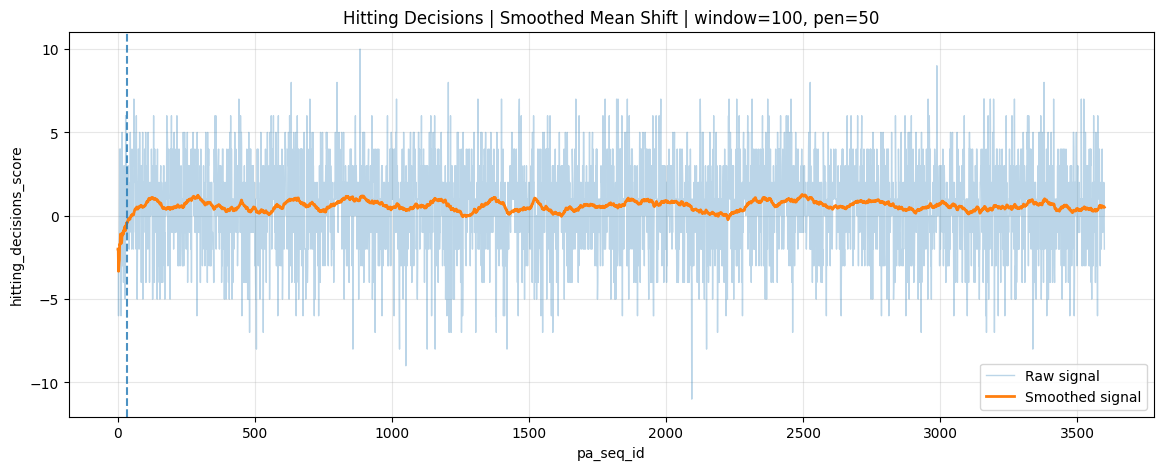

pen=10, #internal_bkpts=8
pen=20, #internal_bkpts=4
pen=50, #internal_bkpts=1
pen=100, #internal_bkpts=1
pen=200, #internal_bkpts=0
pen=500, #internal_bkpts=0
pen=1000, #internal_bkpts=0


In [39]:
#!/usr/bin/env python
# coding: utf-8

# ============================================================
# CPD Mean Shift Pipeline (Smoothed Signal + PELT)
# ============================================================

import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ruptures as rpt


# ============================================================
# 1. Load data
# ============================================================
DATA_FILE = 'Qualified_hitters_statcast_2021_2025_pa_master.csv'
csv_path = Path(os.getcwd()).parent / 'data' / 'processed' / DATA_FILE
df = pd.read_csv(csv_path)


# ============================================================
# 2. Build CPD subdatasets for one selected player
# ============================================================
def cpd_subdataset_generator(df, selected_player_id):
    """
    Generate four CPD subdatasets for one player.

    Parameters
    ----------
    df : pandas.DataFrame
        Original PA-level dataframe.
    selected_player_id : int
        MLBAM batter id.

    Returns
    -------
    dict[str, pandas.DataFrame]
        Keys: cpd_decision, cpd_power_efficiency,
              cpd_woba_residual, cpd_launch_angle_stability
    """
    base_cols = ["batter", "pa_uid", "game_date", "game_pk", "at_bat_number"]

    def _build_subdataset(x_col, y_col):
        return (
            df.loc[df["batter"] == selected_player_id, base_cols + [x_col, y_col]]
              .dropna(subset=[x_col, y_col])
              .sort_values(x_col)
              .reset_index(drop=True)
        )

    return {
        "cpd_decision": _build_subdataset("pa_seq_id", "hitting_decisions_score"),
        "cpd_power_efficiency": _build_subdataset("power_woba_seq_id", "power_efficiency"),
        "cpd_woba_residual": _build_subdataset("power_woba_seq_id", "woba_residual"),
        "cpd_launch_angle_stability": _build_subdataset("launch_angle_seq_id", "launch_angle_stability_50pa"),
    }


# ============================================================
# 3. Mean-shift smoothing
# ============================================================
def apply_mean_shift_smoothing(subdf, y_col, window=50, min_periods=1):
    """
    Apply rolling mean smoothing to a CPD subdataset.

    Parameters
    ----------
    subdf : pandas.DataFrame
        Time-ordered CPD subdataset.
    y_col : str
        Signal column.
    window : int
        Rolling window size.
    min_periods : int
        Minimum observations required for rolling mean.

    Returns
    -------
    pandas.DataFrame
        Original dataframe with an added smoothed column.
    """
    out = subdf.copy()
    out[f"{y_col}_smoothed"] = (
        out[y_col]
        .rolling(window=window, min_periods=min_periods)
        .mean()
    )
    return out


# ============================================================
# 4. Build signal for CPD
# ============================================================
def build_cpd_signal(subdf, x_col, y_col):
    """
    Build univariate signal array for ruptures.

    Parameters
    ----------
    subdf : pandas.DataFrame
        CPD subdataset.
    x_col : str
        Sequential index column.
    y_col : str
        Signal column.

    Returns
    -------
    signal_df : pandas.DataFrame
        Clean dataframe containing x and y.
    signal : np.ndarray
        Shape (n, 1), ready for ruptures.
    """
    signal_df = (
        subdf[[x_col, y_col]]
        .dropna()
        .sort_values(x_col)
        .reset_index(drop=True)
        .copy()
    )

    signal = signal_df[y_col].to_numpy().reshape(-1, 1)
    return signal_df, signal


# ============================================================
# 5. Run PELT mean-shift CPD
# ============================================================
def run_pelt_mean_shift(signal, pen=50):
    """
    Run mean-shift CPD using PELT with L2 cost.

    Parameters
    ----------
    signal : np.ndarray
        Shape (n, 1)
    pen : int | float
        Penalty controlling number of breakpoints.

    Returns
    -------
    list[int]
        Breakpoint indices returned by ruptures.
    """
    algo = rpt.Pelt(model="l2").fit(signal)
    bkpts = algo.predict(pen=pen)
    return bkpts


# ============================================================
# 6. Plot function
# ============================================================
def plot_cp_result(signal_df, x_col, raw_y_col, smooth_y_col, bkpts, title="CPD Result"):
    """
    Plot raw signal, smoothed signal, and detected breakpoints.
    """
    fig, ax = plt.subplots(figsize=(14, 5))

    ax.plot(signal_df[x_col], signal_df[raw_y_col], linewidth=1.0, alpha=0.30, label="Raw signal")
    ax.plot(signal_df[x_col], signal_df[smooth_y_col], linewidth=2.0, label="Smoothed signal")

    for bp in bkpts[:-1]:
        ax.axvline(signal_df.iloc[bp - 1][x_col], linestyle="--", alpha=0.8)

    ax.set_title(title)
    ax.set_xlabel(x_col)
    ax.set_ylabel(raw_y_col)
    ax.grid(alpha=0.3)
    ax.legend()
    plt.show()


# ============================================================
# 7. Example: Hitting Decisions
# ============================================================
SELECTED_PLAYER_ID = 660271  # Shohei Ohtani example
WINDOW = 100
PENALTY = 50

cpd_subdatasets = cpd_subdataset_generator(df, SELECTED_PLAYER_ID)
cpd_decision = cpd_subdatasets["cpd_decision"]

# 7.1 Apply smoothing
cpd_decision_smooth = apply_mean_shift_smoothing(
    cpd_decision,
    y_col="hitting_decisions_score",
    window=WINDOW,
    min_periods=1,
)

# 7.2 Build signal from smoothed series
decision_signal_df, decision_signal = build_cpd_signal(
    cpd_decision_smooth,
    x_col="pa_seq_id",
    y_col="hitting_decisions_score_smoothed",
)

# 7.3 Run PELT
decision_bkpts = run_pelt_mean_shift(decision_signal, pen=PENALTY)
decision_internal_bkpts = decision_bkpts[:-1]

print("decision_bkpts:", decision_bkpts)
print("# of internal change points:", len(decision_internal_bkpts))

# 7.4 Merge raw + smoothed for plotting
plot_df = cpd_decision_smooth[["pa_seq_id", "hitting_decisions_score", "hitting_decisions_score_smoothed"]].dropna().reset_index(drop=True)

plot_cp_result(
    plot_df,
    x_col="pa_seq_id",
    raw_y_col="hitting_decisions_score",
    smooth_y_col="hitting_decisions_score_smoothed",
    bkpts=decision_bkpts,
    title=f"Hitting Decisions | Smoothed Mean Shift | window={WINDOW}, pen={PENALTY}",
)


# ============================================================
# 8. Optional: grid search on penalty
# ============================================================
for pen in [10, 20, 50, 100, 200, 500, 1000]:
    bkpts = run_pelt_mean_shift(decision_signal, pen=pen)
    print(f"pen={pen}, #internal_bkpts={len(bkpts) - 1}")
